# Interpretable Anomaly Detection: SHAP vs Counterfactuals

**Author:** Simon Stronks  
**Dataset:** CIC-IDS2017

Trains a Random Forest on one CIC-IDS2017 CSV, explains predictions with **SHAP** (`TreeExplainer`), and generates diverse counterfactuals with **DiCE**. The last section compares global SHAP importance with DiCE perturbations (top‑$k$ overlap + Spearman $\rho$), matching the written report.

In [19]:
from pathlib import Path

import dice_ml
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split

# Notebook-only display settings (these don't affect the data or model; they just make tables easier to read).
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

## 1. Load and Clean CIC-IDS2017 Data

Use one manageable CIC-IDS2017 CSV file instead of the full dataset. The code below strips column whitespace, removes infinite values, and drops invalid rows before modeling.

In [20]:
DATA_PATH = Path("Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv")
SAMPLE_SIZE = 50_000
RANDOM_STATE = 42

df = pd.read_csv(DATA_PATH, encoding="utf-8", low_memory=False)
df.columns = df.columns.str.strip()
df = df.replace([np.inf, -np.inf], np.nan).dropna()

print(f"Cleaned dataset shape: {df.shape}")
print(df["Label"].value_counts().head())

Cleaned dataset shape: (170231, 79)
Label
BENIGN                        168051
Web Attack � Brute Force        1507
Web Attack � XSS                 652
Web Attack � Sql Injection        21
Name: count, dtype: int64


## 2. Sample, Encode Labels, and Train/Test Split

Sample up to `SAMPLE_SIZE` rows (stratified holdout comes next). Labels: `BENIGN` → `0`, any attack → `1`. Then an 80/20 **stratified** split keeps class proportions in both sets.

In [21]:
sample_size = min(SAMPLE_SIZE, len(df))
df_sample = df.sample(n=sample_size, random_state=RANDOM_STATE).copy()

df_sample["Label"] = df_sample["Label"].astype(str).str.strip().str.upper()
df_sample["Label"] = (df_sample["Label"] != "BENIGN").astype(int)

X = df_sample.drop(columns=["Label"])
y = df_sample["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Sampled rows: {len(df_sample):,}")
print("Class balance:")
print(y.value_counts(normalize=True).rename("share"))
print(f"Training shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Sampled rows: 50,000
Class balance:
Label
0    0.9869
1    0.0131
Name: share, dtype: float64
Training shape: (40000, 78)
Test shape: (10000, 78)


## 3. Train Random Forest Classifier

`X_train` / `X_test` are already built in §2. A Random Forest is a strong baseline on tabular CIC features and pairs cleanly with `shap.TreeExplainer` (same hyperparameters as in the report).

In [22]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)

print("Random Forest training complete.")

Random Forest training complete.


## 4. Evaluate Classification Performance

Before explanation, verify that the classifier is separating benign and malicious traffic reasonably well on the held-out test set.

              precision    recall  f1-score   support

           0     0.9993    1.0000    0.9996      9869
           1     1.0000    0.9466    0.9725       131

    accuracy                         0.9993     10000
   macro avg     0.9996    0.9733    0.9861     10000
weighted avg     0.9993    0.9993    0.9993     10000



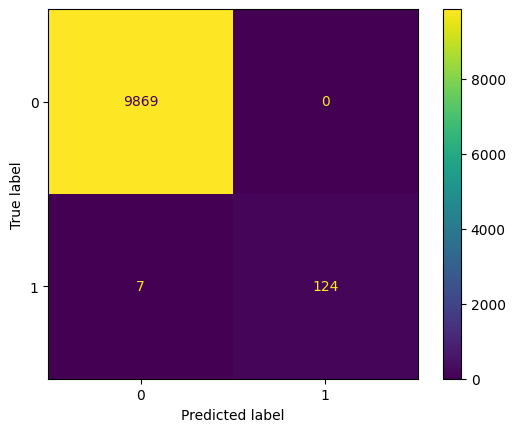

In [23]:
y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred, digits=4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

## 5. Generate SHAP Global and Local Explanations

The summary plot highlights the most influential features overall. The local explanation focuses on one malicious flow from the test set.

Global SHAP summary plot:


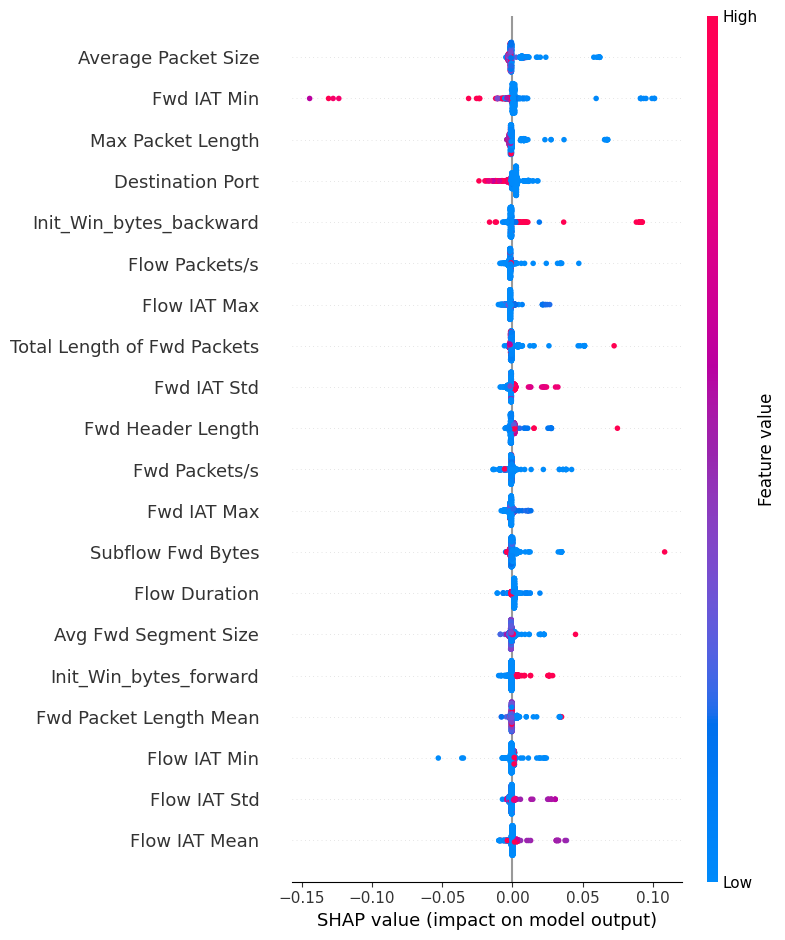

Local SHAP explanation for one malicious flow:


In [24]:
shap.initjs()
explainer = shap.TreeExplainer(rf_model)

shap_sample_size = min(1000, len(X_test))
X_test_sample = X_test.sample(n=shap_sample_size, random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_test_sample)

if isinstance(shap_values, list):
    shap_values_attack = shap_values[1]
else:
    shap_values_attack = shap_values[..., 1]

print("Global SHAP summary plot:")
shap.summary_plot(shap_values_attack, X_test_sample, show=False)
plt.tight_layout()
plt.show()

malicious_candidates = y_test[y_test == 1]
if malicious_candidates.empty:
    raise ValueError("No malicious samples were found in the test split. Use a dataset sample that includes attacks.")

malicious_index = malicious_candidates.index[0]
malicious_flow = X_test.loc[[malicious_index]]
shap_values_local = explainer.shap_values(malicious_flow)

if isinstance(shap_values_local, list):
    local_attack_values = shap_values_local[1]
    expected_value = explainer.expected_value[1]
else:
    local_attack_values = shap_values_local[..., 1]
    expected_value = explainer.expected_value[1] if np.ndim(explainer.expected_value) > 0 else explainer.expected_value

print("Local SHAP explanation for one malicious flow:")
shap.force_plot(expected_value, local_attack_values, malicious_flow)

## 6. Prepare DiCE Data/Model Interfaces

DiCE needs the training data schema and a wrapped model before it can search for counterfactual examples.

In [25]:
train_dataset = X_train.copy()
train_dataset["Label"] = y_train.values

# DiCE: all flow features are treated as numeric/continuous (standard for this assignment).
continuous_features = X.columns.tolist()
dice_data = dice_ml.Data(
    dataframe=train_dataset,
    continuous_features=continuous_features,
    outcome_name="Label",
)
dice_model = dice_ml.Model(model=rf_model, backend="sklearn")
# Random backend: sklearn RandomForest is not end-to-end differentiable.
dice_explainer = dice_ml.Dice(dice_data, dice_model, method="random")

## 7. Generate Counterfactual Explanations for Malicious Flows

This asks the model what minimal feature changes would make the selected malicious flow be classified as benign.

In [26]:
FEATURE_ORDER = list(X.columns)

print("Original malicious flow:")
display(malicious_flow)

orig_class = rf_model.predict(malicious_flow[FEATURE_ORDER])[0]
print(f"\nForest prediction for original row (1=attack, 0=benign): {int(orig_class)}")

print("\nGenerating counterfactuals toward the benign class...")
dice_result = dice_explainer.generate_counterfactuals(
    malicious_flow,
    total_CFs=2,
    desired_class=0,
)
dice_result.visualize_as_dataframe(show_only_changes=True)

# Validity: counterfactual rows should be classified as benign (0).
_cfs = dice_result.cf_examples_list[0].final_cfs_df
_cf_X = _cfs[FEATURE_ORDER].astype(float)
_cf_pred = rf_model.predict(_cf_X)
print("\nValidity check — predicted class per counterfactual (expect 0):")
for i, p in enumerate(_cf_pred):
    print(f"  CF {i + 1}: {int(p)} {'OK' if p == 0 else 'NOT FLIPPED'}")

Original malicious flow:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
84913,80,5662693,3,1,0,0,0,0,0.0,0.0,...,0,32,0.0,0.0,0,0,0.0,0.0,0,0



Forest prediction for original row (1=attack, 0=benign): 1

Generating counterfactuals toward the benign class...


100%|██████████| 1/1 [00:00<00:00,  1.33it/s]

Query instance (original outcome : 1)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,5662693,3,1,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,1



Diverse Counterfactual set (new outcome: 0)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0
1,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0



Validity check — predicted class per counterfactual (expect 0):
  CF 1: 0 OK
  CF 2: 0 OK


## 8. Cross-method comparison (SHAP vs. DiCE)

Compare **which features** each method stresses: global mean |SHAP| (attack class) vs. largest changes in each DiCE counterfactual. Reports top‑$k$ overlap and Spearman $\rho$ between mean |SHAP| and mean perturbation magnitude — same idea as the report’s between-method comparison.

In [27]:
from scipy.stats import spearmanr

TOP_K = 5
feat_cols = list(X_test_sample.columns)
assert feat_cols == list(X.columns), "SHAP sample columns must match training features."

mean_abs_shap = np.abs(shap_values_attack).mean(axis=0)
order_shap = np.argsort(-mean_abs_shap)
top_shap = {feat_cols[i] for i in order_shap[:TOP_K]}

print(f"Top-{TOP_K} features by global mean |SHAP| (attack class):")
for r, idx in enumerate(order_shap[:TOP_K], start=1):
    print(f"  {r}. {feat_cols[idx]}: {mean_abs_shap[idx]:.6f}")

cex = dice_result.cf_examples_list[0]
orig = cex.test_instance_df
cfs = cex.final_cfs_df
feat_only = [c for c in feat_cols if c in orig.columns]
vec_orig = orig.iloc[0][feat_only].astype(float).to_numpy()

pert_vectors = []
for j in range(len(cfs)):
    row = cfs.iloc[j][feat_only].astype(float).to_numpy()
    delta = np.abs(row - vec_orig)
    pert_vectors.append(delta)
    order_cf = np.argsort(-delta)
    top_cf = {feat_only[i] for i in order_cf[:TOP_K]}
    inter = top_shap & top_cf
    print(f"\nCounterfactual {j + 1}: top-{TOP_K} overlap with top-{TOP_K} SHAP: {len(inter)}/{TOP_K}")
    if inter:
        print(f"  Overlapping features: {sorted(inter)}")

mean_delta = np.mean(pert_vectors, axis=0)
idx_map = [feat_cols.index(f) for f in feat_only]
shap_vec = np.array([mean_abs_shap[i] for i in idx_map])
rho, pval = spearmanr(shap_vec, mean_delta, nan_policy="omit")
print(
    f"\nSpearman rho (mean |SHAP| vs mean |Δ| across CFs, aligned features): "
    f"{rho:.4f} (p = {pval:.3g})"
)

Top-5 features by global mean |SHAP| (attack class):
  1. Average Packet Size: 0.002562
  2. Fwd IAT Min: 0.002551
  3. Max Packet Length: 0.002489
  4. Destination Port: 0.002362
  5. Init_Win_bytes_backward: 0.002185

Counterfactual 1: top-5 overlap with top-5 SHAP: 1/5
  Overlapping features: ['Fwd IAT Min']

Counterfactual 2: top-5 overlap with top-5 SHAP: 1/5
  Overlapping features: ['Fwd IAT Min']

Spearman rho (mean |SHAP| vs mean |Δ| across CFs, aligned features): 0.3175 (p = 0.00461)
